In [5]:
import numpy as np
import matplotlib.pyplot as plt
import librosa

In [2]:
#url = "https://raw.githubusercontent.com/librosa/data/main/audio/Hungarian_Dance_number_5_-_Allegro_in_F_sharp_minor_(string_orchestra).hq.ogg"
#response = requests.get(url, stream=True)

#with open("data/music/Hungarian_Dance_number_5.ogg", "wb") as f:
#    f.write(response.content)

In [3]:
# загрузка аудиофайла
audio_path = '../data/Hungarian_Dance_number_5.ogg'

# метод возвращает загруженный сигнал и расчётный sample rate

signal, sample_rate = librosa.load(audio_path, sr=None)

print(f"Частота дискретизации: {sample_rate} Гц")
print(f"Количество сэмплов: {len(signal)}")
print(f"Длительность: {len(signal)/sample_rate:.2f} секунд") 

c:\Users\aseva\Desktop\MyEDU\YaDLE\YaDLE_gensim_vscode_stream_4\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Частота дискретизации: 44100 Гц
Количество сэмплов: 2021760
Длительность: 45.84 секунд


Рассчитать Mel-спектрограмму поможет метод `librosa.feature.melspectrogram` из библиотеки `librosa`. Он принимает на вход несколько параметров: 
* загруженный файл,
* его `sample rate`,
* размер окна для Фурье-преобразования `n_fft`,
* шаг сдвига между окнами `hop_length`,
* а также число фильтров `n_mels` для взвешивания спектра.

Перевести Mel-спектрограмму в децибелы можно функцией `power_to_db`. В качестве референсной точки используем максимум из самого спектра. Референсная точка помогает нормализовать уровни громкости в едином масштабе и упростить визуальный анализ спектрограммы. 

Визуализируем через `librosa.display.specshow`.

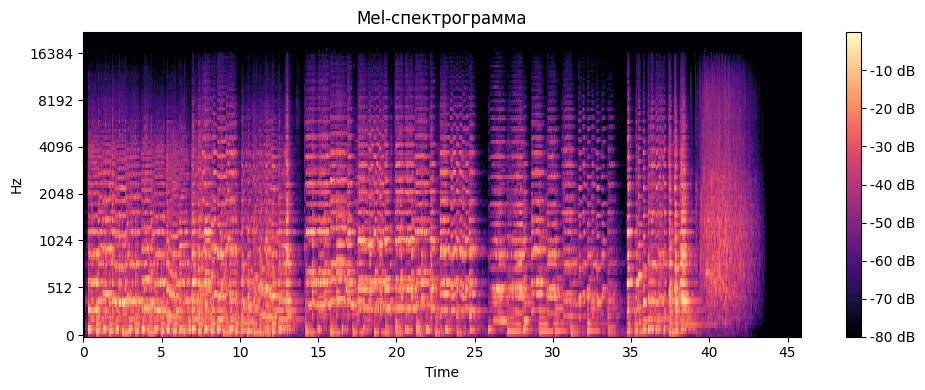

In [6]:
# Параметры для спектрограммы
n_fft = 2048  # размер окна для FFT

hop_length = 512  # шаг между окнами
n_mels = 128  # количество Mel-фильтров
  
# Вычисление Mel-спектрограммы
mel_spec = librosa.feature.melspectrogram(y=signal, 
                                          sr=sample_rate,
                                          n_fft=n_fft,
                                          hop_length=hop_length,
                                          n_mels=n_mels)

# Преобразование в децибелы
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

# Визуализация
plt.figure(figsize=(10, 4))
librosa.display.specshow(mel_spec_db, sr=sample_rate,
                        hop_length=hop_length,
                        x_axis='time', y_axis='mel')

plt.colorbar(format='%+2.0f dB')
plt.title('Mel-спектрограмма')
plt.tight_layout()
plt.show() 

Параметры Mel-спектрограммы определяются задачей:
* Размер окна для Фурье-преобразования `n_fft`, число фильтров для взвешивания спектра `n_mels` — чем выше эти параметры, тем лучше точность частотного анализа, но хуже временная составляющая. Другими словами, чем выше параметры, тем чётче можно различить близкие частоты, но тем сложнее точно отследить момент, когда возник звук. Стандарт значений: `n_fft=2048`, `n_mels=128`.
* Шаг сдвига между окнами `hop_lenght` — чем он меньше, тем плавнее переход спектрограммы по времени, но больше размер данных. Можно начинать с `n_fft / 4`.
* Иногда на практике целесообразно загружать не весь сигнал, а только его часть — ведь аудио может быть и 2 часа длиной. Для этого в метод `librosa.load` можно передать аргументы `offset` — сдвиг начала загрузки файла в секундах и `duration` — длительность.

# Задание 1
* Загрузите аудиофайл с помощью librosa (путь до файла в прекоде). 
* Ограничьте время при загрузке с 35 по 40 секунду. 
* Постройте Mel-спектрограмму с произвольными параметрами и визуализируйте её.
* Задайте offset и duration по условию задачи.

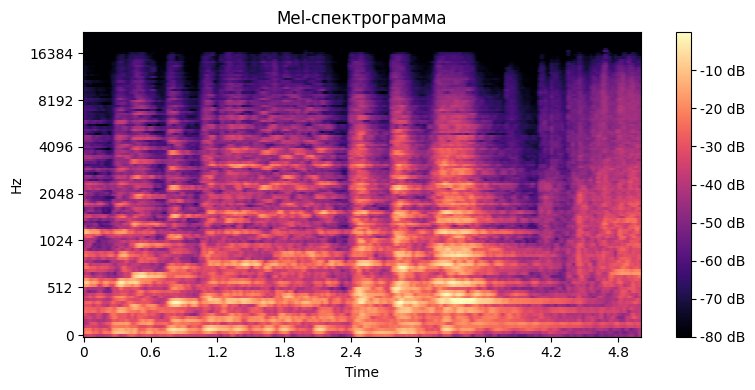

In [14]:
signal, sample_rate = librosa.load(audio_path, offset=35, duration=5, sr=None)

n_fft = 4096 
hop_length = 256 
n_mels = 128

mel_spec = librosa.feature.melspectrogram(y=signal, sr=sample_rate,
                    n_fft=n_fft,
                    hop_length=hop_length,
                    n_mels=n_mels)

mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

plt.figure(figsize=(8, 4))

librosa.display.specshow(mel_spec_db, sr=sample_rate,
            hop_length=hop_length,
            x_axis='time', y_axis='mel')

#plt.yticks([440*(2**n/12) for n in range(12)])   # ноты

plt.colorbar(format='%+2.0f dB')
plt.title('Mel-спектрограмма')
plt.tight_layout()
plt.show() 

проделаем все операции в ручном режиме (сглаживание + STFT → спектр энергий → mel-фильтры → перевод в децибелы) с помощью librosa: функций stft и filter.mel. Результат сравним с рассчитанной автоматически спектрограммой. В качестве входных параметров всех функций, используем уже заданные ранее переменные:

In [18]:
# вычисление STFT (сглаживание по умолчанию)
stft = librosa.stft(signal, n_fft=n_fft, hop_length=hop_length,
                   win_length=n_fft)

# спектрограмма энергий
power_spec = np.abs(stft)**2

# Mel-фильтры
mel_basis = librosa.filters.mel(sr=sample_rate, n_fft=n_fft, n_mels=n_mels)

# взвешивание энергетического спектра с помощью Mel-фильтров)
mel_spec = np.dot(mel_basis, power_spec)

# переход в децибелы
mel_spec_db_manual = librosa.power_to_db(mel_spec, ref=np.max)

# сравнение спектрограмм
result = np.testing.assert_array_equal(mel_spec_db, mel_spec_db_manual)
print(result)

None


# Задание 2
Загрузите аудиофайл с соло на трубе: с помощью librosa или по прямой ссылке. Постройте Mel-спектрограмму с произвольными параметрами и визуализируйте её.

Передайте загруженный аудиофайл в метод melspectrogram и переведите в децибелы.

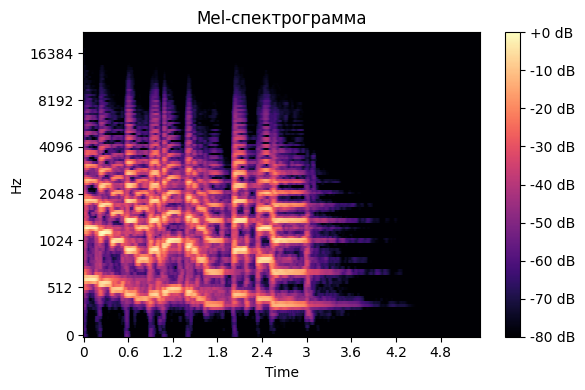

In [19]:
audio_path = '../data/solo_trumpet.ogg'
signal, sample_rate = librosa.load(
    path=audio_path,
    sr=None)

n_fft = 4096 
hop_length = 256 
n_mels = 128

mel_spec = librosa.feature.melspectrogram(y=signal, sr=sample_rate,
                    n_fft=n_fft,
                    hop_length=hop_length,
                    n_mels=n_mels)

mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

plt.figure(figsize=(6, 4))
librosa.display.specshow(mel_spec_db, sr=sample_rate,
            hop_length=hop_length,
            x_axis='time', y_axis='mel')

plt.colorbar(format='%+2.0f dB')
plt.title('Mel-спектрограмма')
plt.tight_layout()
plt.show() 

# Другие типы конвертации аудиоданных
В примерах и заданиях мы конвертировали аудиоданные в Mel-спектрограмму, но есть и другие типы конвертации. Обсудим подробнее их особенности и области применения.
* `STFT` — оконное преобразование Фурье, просто позволяет извлечь частотный спектр без дополнительных адаптаций как в Mel-спектрограмме, не сокращает размерность сигнала. Больше подходит для полного частотного анализа, меньше — для использования для нейросетей.
* `CQT[deep-learning_CQT]` — перевод в частотный спектр, наиболее подходящий для обработки музыки. В этой спектрограмме центры частот распределены логарифмически, отражая восприятие звука человеком.
* `MFCC[deep-learning_MFCC]` — сокращённая версия Mel-спектрограммы, используемая для обработки речи.

Посмотрим, как выглядят другие спектрограммы. STFT-спектр мы уже получали, когда поступательно вычисляли Mel-спектрограмму. Теперь давайте построим CQT-спектрограмму. Для этого используем метод librosa.cqt. Он также принимает на вход несколько параметров: сам сигнал, sampling rate и шаг между окнами hop_length, а возвращает комплексное частотное представление сигнала, от которого мы будем брать модуль. Используем ранее загруженный аудиофайл с игрой на трубе и визуализируем полученную спектрограмму.

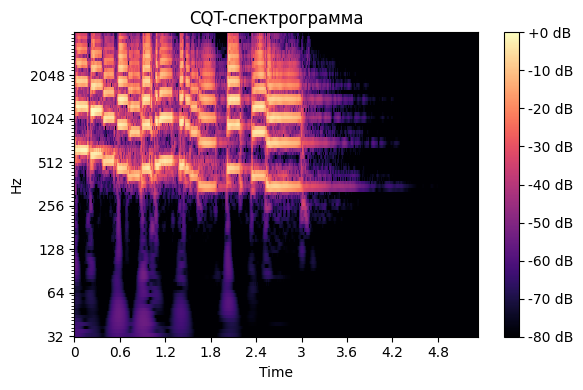

In [20]:
signal, sample_rate = librosa.load(
    path=audio_path,
    sr=None)

# вычисление cqt-спектрограммы
hop_length = 64
cqt_spec = librosa.cqt(y=signal, sr=sample_rate,
                    hop_length=hop_length)

# преобразование в децибелы
cqt_spec_db = librosa.amplitude_to_db(np.abs(cqt_spec), ref=np.max)

# визуализация
plt.figure(figsize=(6, 4))
librosa.display.specshow(cqt_spec_db, sr=sample_rate,
            hop_length=hop_length,
            x_axis='time', y_axis='cqt_hz')

plt.colorbar(format='%+2.0f dB')
plt.title('CQT-спектрограмма')
plt.tight_layout()
plt.show() 